# Task 2: Building a Machine Learning Model

## Step 1: Import Required Libraries

In [48]:

# Import pandas for data manipulation and analysis
import pandas as pd

# Import numpy for numerical operations
import numpy as np

# Import train_test_split for splitting data into training and testing sets
# GridSearchCV for hyperparameter tuning, cross_val_score for cross-validation
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

# Import preprocessing tools: LabelEncoder for categorical encoding, StandardScaler for numerical scaling
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Import metrics for model evaluation: classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Import XGBoost classifier for building the machine learning model
from xgboost import XGBClassifier

# Import matplotlib.pyplot for plotting
import matplotlib.pyplot as plt

# Import seaborn for advanced data visualizations
import seaborn as sns

## Step 2: Data Loading and Initial Exploration

In [49]:


# Load customer demographics data from the 'Customer_Demographics' sheet of the Excel file
# This sheet contains basic customer information like Age, Gender, MaritalStatus, IncomeLevel
data = pd.read_excel("Customer_Churn_Data_Large.xlsx", sheet_name='Customer_Demographics')

# Load churn status data from the 'Churn_Status' sheet
# This sheet contains the target variable ChurnStatus (1 for churn, 0 for no churn)
churn_data = pd.read_excel("Customer_Churn_Data_Large.xlsx", sheet_name='Churn_Status')

# Merge the two datasets on the 'CustomerID' column to combine demographics with churn status
data = data.merge(churn_data, on='CustomerID')

# Create a copy of the original merged data for use in visualizations (before preprocessing)
original_data = data.copy()

# Display the first 5 rows of the dataset to understand its structure
print("First 5 rows of the dataset:")
print(data.head())

# Display the column names to see all available features
print("\nColumn names:")
print(data.columns.tolist())

# Display basic information about the dataset (shape, data types, missing values)
print("\nDataset info:")
print(data.info())

# Check for missing values in each column
print("\nMissing values per column:")
print(data.isnull().sum())

First 5 rows of the dataset:
   CustomerID  Age Gender MaritalStatus IncomeLevel  ChurnStatus
0           1   62      M        Single         Low            0
1           2   65      M       Married         Low            1
2           3   18      M        Single         Low            0
3           4   21      M       Widowed         Low            0
4           5   21      M      Divorced      Medium            0

Column names:
['CustomerID', 'Age', 'Gender', 'MaritalStatus', 'IncomeLevel', 'ChurnStatus']

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerID     1000 non-null   int64 
 1   Age            1000 non-null   int64 
 2   Gender         1000 non-null   object
 3   MaritalStatus  1000 non-null   object
 4   IncomeLevel    1000 non-null   object
 5   ChurnStatus    1000 non-null   int64 
dtypes: int64(3), objec

## Step 3: Data Preprocessing

In [50]:
# Encode categorical variables to numerical values for machine learning
# Categorical columns: Gender, MaritalStatus, IncomeLevel
categorical_cols = ['Gender', 'MaritalStatus', 'IncomeLevel']

# Initialize the LabelEncoder
encoder = LabelEncoder()

# Loop through each categorical column and transform it
for col in categorical_cols:
    data[col] = encoder.fit_transform(data[col])
    print(f"Encoded {col}: {dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))}")

# Scale numerical features to have mean 0 and variance 1
# Numerical columns: Age (AmountSpent not available in this dataset)
scaler = StandardScaler()
num_cols = ['Age']

# Fit the scaler on the training data and transform
data[num_cols] = scaler.fit_transform(data[num_cols])
print(f"Scaled numerical columns: {num_cols}")

# Separate features (X) and target (y)
# Drop CustomerID (not useful for prediction) and ChurnStatus (target)
X = data.drop(columns=['CustomerID', 'ChurnStatus'])
y = data['ChurnStatus']

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) distribution: {y.value_counts()}")

Encoded Gender: {'F': np.int64(0), 'M': np.int64(1)}
Encoded MaritalStatus: {'Divorced': np.int64(0), 'Married': np.int64(1), 'Single': np.int64(2), 'Widowed': np.int64(3)}
Encoded IncomeLevel: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}
Scaled numerical columns: ['Age']
Features (X) shape: (1000, 4)
Target (y) distribution: ChurnStatus
0    796
1    204
Name: count, dtype: int64


## Step 4: Feature Selection and Train-Test Split

In [51]:
# Split the dataset into training and testing sets
# test_size=0.2 means 20% for testing, 80% for training
# stratify=y ensures balanced classes in both sets
# random_state=42 for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Training set shape: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Testing set shape: X_test={X_test.shape}, y_test={y_test.shape}")
print(f"Training class distribution: {y_train.value_counts(normalize=True)}")
print(f"Testing class distribution: {y_test.value_counts(normalize=True)}")

Training set shape: X_train=(800, 4), y_train=(800,)
Testing set shape: X_test=(200, 4), y_test=(200,)
Training class distribution: ChurnStatus
0    0.79625
1    0.20375
Name: proportion, dtype: float64
Testing class distribution: ChurnStatus
0    0.795
1    0.205
Name: proportion, dtype: float64


## Step 5: Model Training

In [52]:
# Initialize the XGBoost Classifier
# eval_metric='logloss' for binary classification, use_label_encoder=False to avoid warnings
xgb = XGBClassifier(eval_metric='logloss', use_label_encoder=False)

# Define hyperparameters for tuning
# max_depth: tree depth, learning_rate: step size, n_estimators: number of trees, subsample: fraction of samples
params = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200, 300],
    'subsample': [0.8, 1.0]
}

# Perform Grid Search with Cross-Validation
# cv=5: 5-fold cross-validation, scoring='roc_auc' for area under ROC curve
# n_jobs=-1: use all available CPU cores, verbose=1: show progress
grid = GridSearchCV(xgb, params, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)

# Get the best model from grid search
best_model = grid.best_estimator_

# Print the best hyperparameters found
print("Best Hyperparameters from Grid Search:")
print(grid.best_params_)

# Print the best cross-validation score
print(f"Best Cross-Validation ROC-AUC Score: {grid.best_score_:.4f}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [17:12:41] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [17:12:41] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [17:12:41] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [17:12:41] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i

Best Hyperparameters from Grid Search:
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
Best Cross-Validation ROC-AUC Score: 0.5816


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [17:12:42] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [17:12:42] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [17:12:42] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [17:12:42] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i

## Step 6: Model Evaluation

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.98      0.88       159
           1       0.25      0.02      0.04        41

    accuracy                           0.79       200
   macro avg       0.52      0.50      0.46       200
weighted avg       0.68      0.79      0.71       200


Confusion Matrix:
 [[156   3]
 [ 40   1]]

ROC-AUC Score: 0.4501


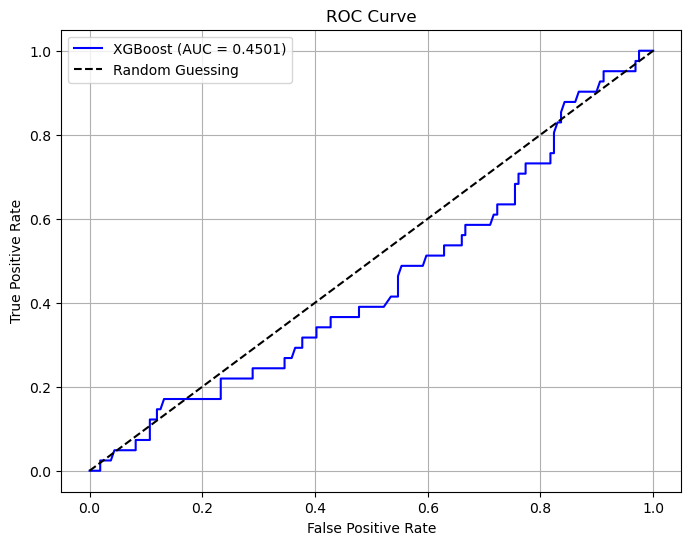

In [ ]:


# Generate predictions on the test set using the trained model
y_pred = best_model.predict(X_test)  # Binary predictions: 0 (no churn) or 1 (churn)

# Generate probability predictions for the positive class (churn)
y_proba = best_model.predict_proba(X_test)[:, 1]  # Probabilities range from 0 to 1

# Print a detailed classification report including precision, recall, f1-score, and support for each class
print("Classification Report:\n", classification_report(y_test, y_pred))

# Print the confusion matrix showing true positives, false positives, true negatives, false negatives
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Calculate and print the ROC-AUC score, which measures the model's ability to distinguish between classes
roc_auc = roc_auc_score(y_test, y_proba)
print(f"\nROC-AUC Score: {roc_auc:.4f}")

# Plot the ROC Curve to visualize the trade-off between true positive rate and false positive rate
fpr, tpr, thresholds = roc_curve(y_test, y_proba)  # Calculate false positive rate, true positive rate, and thresholds
plt.figure(figsize=(8, 6))  # Set figure size
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc:.4f})', color='blue')  # Plot the ROC curve
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')  # Plot the diagonal line for random guessing
plt.xlabel('False Positive Rate')  # Label x-axis
plt.ylabel('True Positive Rate')  # Label y-axis
plt.title('ROC Curve')  # Set title
plt.legend()  # Show legend
plt.grid(True)  # Add grid for better readability
plt.show()  # Display the plot

## Step 7: Additional Visualizations

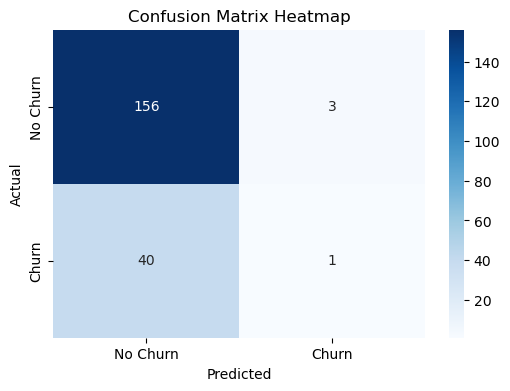

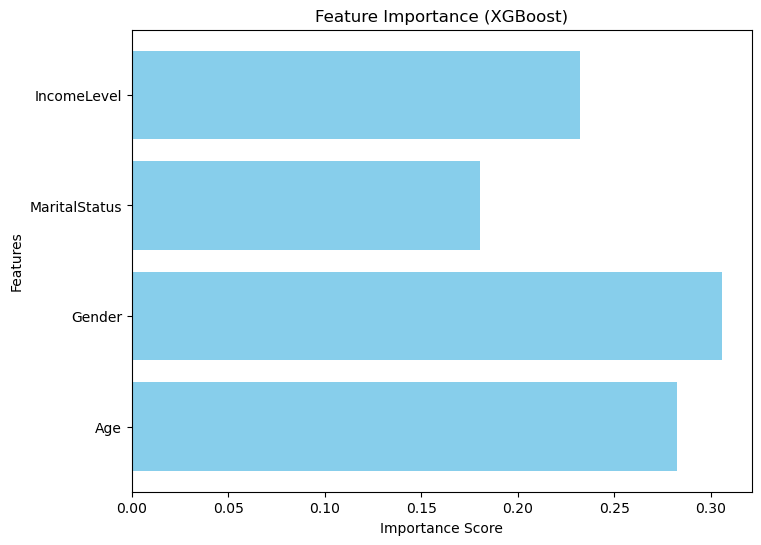

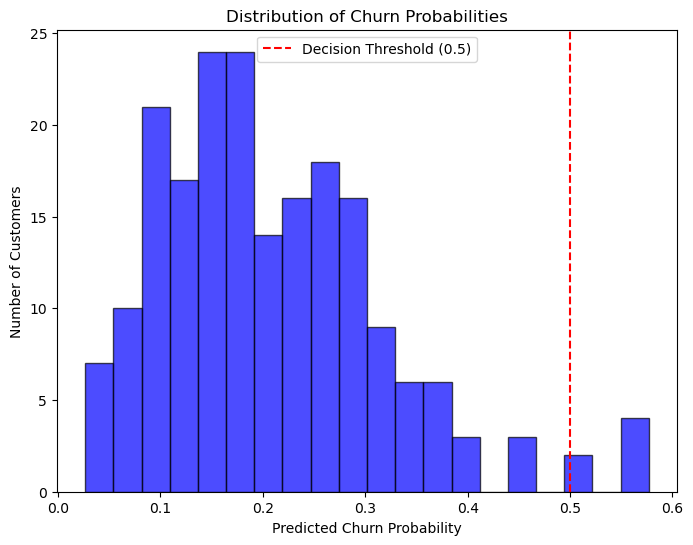

/var/folders/yd/x1bd6gjd1xggv9z2l59x_f080000gn/T/ipykernel_1601/2501023741.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='ChurnStatus', y='Age', data=original_data, palette='Set2')


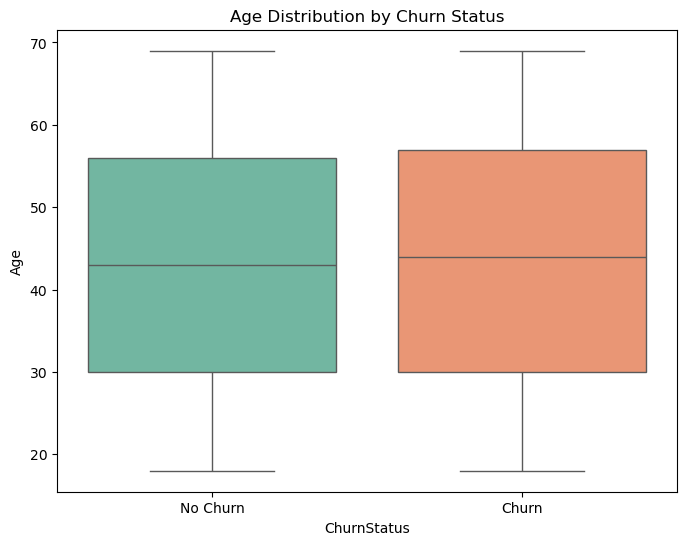

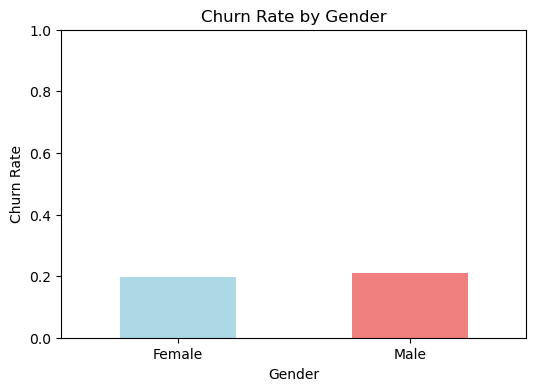

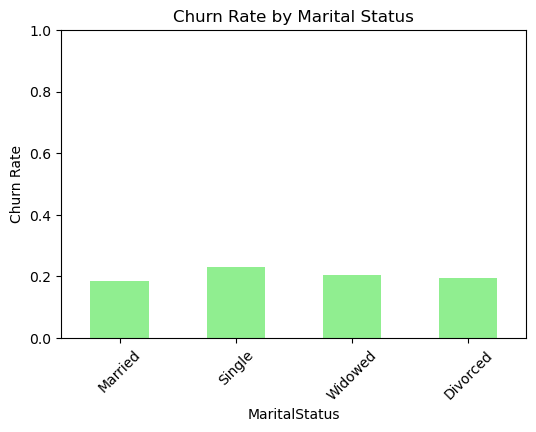

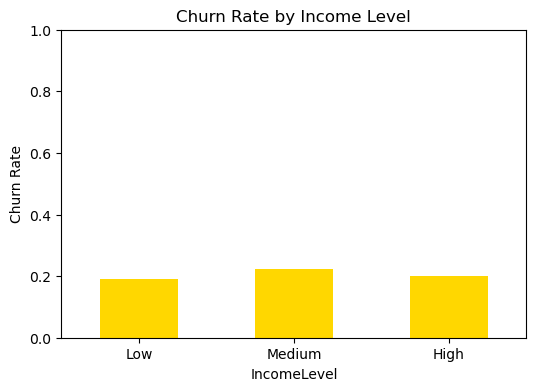

In [54]:


# Confusion Matrix Heatmap
# Visualize the confusion matrix with a heatmap for better understanding
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix Heatmap')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Feature Importance Plot
# Show which features are most important in the model's decision-making
importances = best_model.feature_importances_
features = X.columns
plt.figure(figsize=(8, 6))
plt.barh(features, importances, color='skyblue')
plt.title('Feature Importance (XGBoost)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

# Churn Probability Distribution
# Histogram of predicted probabilities to see model confidence
plt.figure(figsize=(8, 6))
plt.hist(y_proba, bins=20, alpha=0.7, color='blue', edgecolor='black')
plt.title('Distribution of Churn Probabilities')
plt.xlabel('Predicted Churn Probability')
plt.ylabel('Number of Customers')
plt.axvline(x=0.5, color='red', linestyle='--', label='Decision Threshold (0.5)')
plt.legend()
plt.show()

# Age Distribution by Churn Status
# Box plot to compare age distributions between churned and retained customers
plt.figure(figsize=(8, 6))
sns.boxplot(x='ChurnStatus', y='Age', data=original_data, palette='Set2')
plt.title('Age Distribution by Churn Status')
plt.xticks([0, 1], ['No Churn', 'Churn'])
plt.ylabel('Age')
plt.show()

# Churn Rate by Gender
# Bar plot showing churn rates for different genders
gender_churn = original_data.groupby('Gender')['ChurnStatus'].mean()
plt.figure(figsize=(6, 4))
gender_churn.plot(kind='bar', color=['lightblue', 'lightcoral'])
plt.title('Churn Rate by Gender')
plt.ylabel('Churn Rate')
plt.xticks(ticks=[0, 1], labels=['Female', 'Male'], rotation=0)
plt.ylim(0, 1)
plt.show()

# Churn Rate by Marital Status
# Bar plot for churn rates across marital statuses
marital_churn = original_data.groupby('MaritalStatus')['ChurnStatus'].mean()
plt.figure(figsize=(6, 4))
marital_churn.plot(kind='bar', color='lightgreen')
plt.title('Churn Rate by Marital Status')
plt.ylabel('Churn Rate')
plt.xticks(ticks=[0, 1, 2, 3], labels=['Married', 'Single', 'Widowed', 'Divorced'], rotation=45)
plt.ylim(0, 1)
plt.show()

# Churn Rate by Income Level
# Bar plot for churn rates by income levels
income_churn = original_data.groupby('IncomeLevel')['ChurnStatus'].mean()
plt.figure(figsize=(6, 4))
income_churn.plot(kind='bar', color='gold')
plt.title('Churn Rate by Income Level')
plt.ylabel('Churn Rate')
plt.xticks(ticks=[0, 1, 2], labels=['Low', 'Medium', 'High'], rotation=0)
plt.ylim(0, 1)
plt.show()

## Step 8: Business Utilization and Predictions

In [55]:
# Identify at-risk customers based on churn probability
# Flag customers with churn probability > 0.7 as high-risk
at_risk_customers = X_test.copy()
at_risk_customers['Churn_Probability'] = y_proba
at_risk_customers['Churn_Flag'] = (at_risk_customers['Churn_Probability'] > 0.7).astype(int)

# Display the first few at-risk customers
print("Customers at high risk of churn (probability > 0.7):")
high_risk = at_risk_customers[at_risk_customers['Churn_Flag'] == 1]
if not high_risk.empty:
    print(high_risk.head())
else:
    print("No customers with churn probability > 0.7 in the test set.")

# Summary statistics for business insights
print(f"\nTotal test customers: {len(at_risk_customers)}")
print(f"High-risk customers: {len(high_risk)}")
print(f"Percentage at high risk: {len(high_risk) / len(at_risk_customers) * 100:.2f}%")

Customers at high risk of churn (probability > 0.7):
No customers with churn probability > 0.7 in the test set.

Total test customers: 200
High-risk customers: 0
Percentage at high risk: 0.00%


In [56]:

# 8. Predict Churn for New Customers

new_customer = pd.DataFrame({
    'Age': [75],  # Scaled age, but for prediction, we need to scale it
    'Gender': [0],  # Encoded: 0=Female, 1=Male
    'MaritalStatus': [0],  # Encoded: 0=Married, etc.
    'IncomeLevel': [0]  # Encoded: 0=Low, 1=Medium, 2=High
})

# Scale the numerical features for the new customer
new_customer[num_cols] = scaler.transform(new_customer[num_cols])

# Predict churn probability
churn_probability = best_model.predict_proba(new_customer)[:, 1][0]
churn_prediction = best_model.predict(new_customer)[0]

print(f"Churn Probability: {churn_probability * 100:.2f}%")
print(f"Predicted Churn: {'Yes' if churn_prediction == 1 else 'No'}")



Churn Probability: 31.96%
Predicted Churn: No
